# Proyek Analisis Data: [E-Commerce Public Dataset]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Pertanyaan 1**
- How do monthly order volume and total revenue evolve from 2016 to 2018, and what key trends can be identified to support business decision-making?

Keterangan:

- Specific: Fokus pada analisis "jumlah order" dan "total revenue" secara bulanan dalam dataset e-commerce.
- Measurable: Menggunakan metrik kuantitatif seperti jumlah order unik dan total nilai pembayaran setiap bulan.
- Action-Oriented: Hasil analisis dapat digunakan untuk mengidentifikasi tren peningkatan atau penurunan yang dapat mendukung strategi pemasaran atau penjualan.
- Relevant: Memahami tren penjualan sangat penting untuk pengambilan keputusan bisnis dalam e-commerce.
- Time-bound: Analisis dibatasi pada periode tahun 2016 hingga 2018.

**Pertanyaan 2**

- Which product categories contribute the most to total revenue between 2016 and 2018, and how can this information be used to prioritize product strategy?

Keterangan:

- Specific: Fokus pada kategori produk yang memberikan kontribusi terbesar terhadap total revenue.
-Measurable: Diukur berdasarkan total nilai pembayaran dari masing-masing kategori produk.
- Action-Oriented: Hasil analisis dapat digunakan untuk menentukan prioritas produk, seperti meningkatkan stok atau promosi pada kategori dengan performa tinggi.
- Relevant: Mengetahui kategori unggulan penting untuk meningkatkan efektivitas strategi bisnis dan penjualan.
- Time-bound: Analisis dilakukan pada periode 2016 hingga 2018.

**Pertanyaan 3**

- What payment methods are most frequently used by customers from 2016 to 2018, and how can this insight support optimization of payment services?

Keterangan:

- Specific: Fokus pada metode pembayaran yang digunakan oleh pelanggan dalam transaksi e-commerce.
- Measurable: Diukur berdasarkan jumlah penggunaan masing-masing metode pembayaran.
-Action-Oriented: Insight ini dapat digunakan untuk mengoptimalkan layanan pembayaran, seperti meningkatkan dukungan pada metode yang paling sering digunakan.
- Relevant: Metode pembayaran berpengaruh terhadap kenyamanan pelanggan dan keberhasilan transaksi.
- Time-bound: Analisis dibatasi pada periode 2016 hingga 2018.

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
clean_df = pd.read_csv("https://raw.githubusercontent.com/louiee-jason/ecommerce-dashboard-analysis/main/dashboard/clean_data.csv")
customers = pd.read_csv("https://raw.githubusercontent.com/louiee-jason/ecommerce-dashboard-analysis/main/data/customers_dataset.csv")
orders = pd.read_csv("https://raw.githubusercontent.com/louiee-jason/ecommerce-dashboard-analysis/main/data/orders_dataset.csv")
order_items = pd.read_csv("https://raw.githubusercontent.com/louiee-jason/ecommerce-dashboard-analysis/main/data/order_items_dataset.csv")
payments = pd.read_csv("https://raw.githubusercontent.com/louiee-jason/ecommerce-dashboard-analysis/main/data/order_payments_dataset.csv")
reviews = pd.read_csv("https://raw.githubusercontent.com/louiee-jason/ecommerce-dashboard-analysis/main/data/order_reviews_dataset.csv")
products = pd.read_csv("https://raw.githubusercontent.com/louiee-jason/ecommerce-dashboard-analysis/main/data/products_dataset.csv")

In [ ]:
df1 = orders.merge(order_items, on='order_id')
df2 = df1.merge(products, on='product_id')
df3 = df2.merge(customers, on='customer_id')
df = df3.merge(payments, on='order_id')

### Data Understanding

Tahap ini bertujuan untuk memahami struktur data dan isi dari setiap dataset.

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,credit_card,3,179.12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  object 
 1   customer_id                    117601 non-null  object 
 2   order_status                   117601 non-null  object 
 3   order_purchase_timestamp       117601 non-null  object 
 4   order_approved_at              117586 non-null  object 
 5   order_delivered_carrier_date   116356 non-null  object 
 6   order_delivered_customer_date  115034 non-null  object 
 7   order_estimated_delivery_date  117601 non-null  object 
 8   order_item_id                  117601 non-null  int64  
 9   product_id                     117601 non-null  object 
 10  seller_id                      117601 non-null  object 
 11  shipping_limit_date            117601 non-null  object 
 12  price                         

### Feature Selection

Pada tahap ini dilakukan pemilihan kolom yang relevan dengan pertanyaan bisnis. Hal ini bertujuan untuk menyederhanakan dataset serta meningkatkan efisiensi dalam proses analisis.

Kolom yang dipilih meliputi informasi terkait waktu transaksi, customer, produk, pembayaran, serta review.

In [ ]:
df = df[[
    'order_id',
    'customer_id',
    'order_purchase_timestamp',
    'product_category_name',
    'payment_value',
    'customer_city',
    'customer_state',
    'price',
    'freight_value',
    'payment_type',
    'payment_installments'
]]

In [ ]:
df.head()

,order_id,customer_id,order_purchase_timestamp,product_category_name,payment_value,customer_city,customer_state,price,freight_value,payment_type,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,utilidades_domesticas,18.12,sao paulo,SP,29.99,8.72,credit_card,1
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,utilidades_domesticas,2.00,sao paulo,SP,29.99,8.72,voucher,1
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,utilidades_domesticas,18.59,sao paulo,SP,29.99,8.72,voucher,1
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,perfumaria,141.46,barreiras,BA,118.70,22.76,boleto,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,automotivo,179.12,vianopolis,GO,159.90,19.22,credit_card,3


### Assessing Data

In [ ]:
df['product_category_name'].value_counts() #check distribution

,count
product_category_name,
cama_mesa_banho,11823
beleza_saude,9972
esporte_lazer,8945
moveis_decoracao,8744
informatica_acessorios,8082
...,...
portateis_cozinha_e_preparadores_de_alimentos,15
cds_dvds_musicais,14
pc_gamer,10


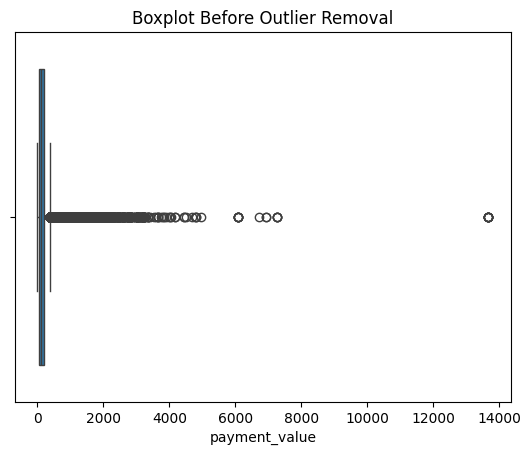

In [ ]:
sns.boxplot(x=df['payment_value']) #check outlier
plt.title('Boxplot Before Outlier Removal')
plt.show()

**Insight:**
- Distribusi nilai pembayaran bersifat right-skewed, dengan mayoritas transaksi berada pada nominal rendah.
- Terdapat outlier dengan nilai transaksi sangat tinggi yang berpotensi mempengaruhi analisis statistik.
- Hal ini menunjukkan adanya perbedaan antara transaksi umum dan transaksi bernilai besar.
- Distribusi kategori produk tidak seimbang, dengan beberapa kategori mendominasi jumlah transaksi.
- Ketidakseimbangan data ini berpotensi menimbulkan bias sehingga perlu diperhatikan dalam analisis.

### Cleaning Data

Tahap ini bertujuan untuk membersihkan data dari missing values, duplikasi, serta memastikan tipe data sudah sesuai untuk analisis.

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_purchase_timestamp,0
product_category_name,1698
payment_value,0
customer_city,0
customer_state,0
price,0
freight_value,0
payment_type,0


In [ ]:
df.duplicated().sum()

np.int64(12045)

In [ ]:
# handle missing values
df['product_category_name'].fillna('unknown', inplace=True)

# cek ulang missing values
df.isnull().sum()

# cek duplicate
df.duplicated().sum()

# convert tipe data timestamp ke datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

/tmp/ipykernel_724/3381715360.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_category_name'].fillna('unknown', inplace=True)


In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_purchase_timestamp,0
product_category_name,0
payment_value,0
customer_city,0
customer_state,0
price,0
freight_value,0
payment_type,0


In [ ]:
df.info() #cek ulang tipe data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  117601 non-null  object        
 1   customer_id               117601 non-null  object        
 2   order_purchase_timestamp  117601 non-null  datetime64[ns]
 3   product_category_name     117601 non-null  object        
 4   payment_value             117601 non-null  float64       
 5   customer_city             117601 non-null  object        
 6   customer_state            117601 non-null  object        
 7   price                     117601 non-null  float64       
 8   freight_value             117601 non-null  float64       
 9   payment_type              117601 non-null  object        
 10  payment_installments      117601 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usag

In [ ]:
# handle outlier
Q1 = df['payment_value'].quantile(0.25)
Q3 = df['payment_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['payment_value'] >= lower_bound) & (df['payment_value'] <= upper_bound)]

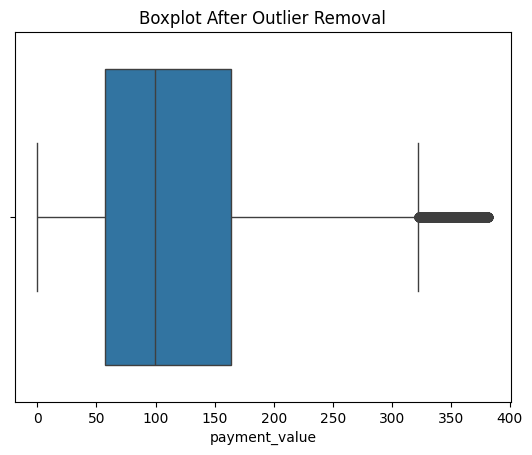

In [ ]:
# check outlier after iqr

sns.boxplot(x=df['payment_value'])
plt.title('Boxplot After Outlier Removal')
plt.show()

**Insight:**
- Missing values pada kolom product_category_name diisi dengan nilai "unknown" agar data tetap lengkap dan dapat digunakan dalam analisis.

- Ditemukan adanya data duplikat dalam dataset. Namun, duplikasi ini tidak langsung dihapus karena kemungkinan merupakan data transaksi yang valid, di mana satu order dapat memiliki lebih dari satu produk atau pembayaran.

- tipe data pada kolom waktu diubah menjadi datetime agar dapat digunakan dalam analisis berbasis waktu.

- Outlier berhasil dikurangi sehingga distribusi data lebih stabil

## Exploratory Data Analysis (EDA)

### Explore Tren Order & Revenue per month

In [ ]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = df.groupby('order_month').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

monthly

,order_month,order_id,payment_value
0,2016-09,2,347.52
1,2016-10,274,40546.05
2,2016-12,1,19.62
3,2017-01,716,106452.71
4,2017-02,1616,221997.20
5,2017-03,2468,339534.55
6,2017-04,2223,313276.94
7,2017-05,3431,472773.43
8,2017-06,3023,392632.92
9,2017-07,3766,520990.52


**Insight:**
- Jumlah order dan revenue menunjukkan tren meningkat dari tahun 2017 hingga awal 2018.
- Puncak transaksi terjadi pada November 2017, dengan jumlah order dan revenue tertinggi dibanding bulan lainnya.
- Setelah mencapai puncak, terjadi fluktuasi namun nilai transaksi tetap relatif tinggi pada tahun 2018.
- Secara keseluruhan, terdapat pola pertumbuhan yang signifikan dalam aktivitas transaksi dari waktu ke waktu.

### Explore Products with biggest revenue

In [ ]:
category_revenue = df.groupby('product_category_name').agg({
    'payment_value': 'sum'
}).sort_values(by='payment_value', ascending=False)

category_revenue.head(10)

,payment_value
product_category_name,
cama_mesa_banho,1377534.58
beleza_saude,1091787.90
moveis_decoracao,1075283.05
esporte_lazer,1031897.55
informatica_acessorios,899333.88
relogios_presentes,792104.85
utilidades_domesticas,770520.52
ferramentas_jardim,522916.03
cool_stuff,514825.88


**Insight:**
- Kategori cama_mesa_banho memiliki kontribusi revenue tertinggi dibandingkan kategori lainnya.
- Beberapa kategori seperti beleza_saude, moveis_decoracao, dan esporte_lazer juga menunjukkan performa penjualan yang tinggi.
- Terdapat perbedaan revenue yang cukup signifikan antara kategori teratas dan kategori di bawahnya.
- Hal ini menunjukkan bahwa penjualan didominasi oleh beberapa kategori utama.

### Explore Payment Methods Distribution


In [ ]:
payment_dist = df['payment_type'].value_counts()

payment_dist

,count
payment_type,
credit_card,79337
boleto,20963
voucher,6195
debit_card,1611


**Insight:**
- Metode pembayaran credit_card mendominasi transaksi dengan jumlah yang jauh lebih tinggi dibanding metode lainnya.
- Metode boleto menjadi pilihan kedua, namun selisihnya cukup signifikan dibanding credit card.
- Metode voucher dan debit_card digunakan dalam jumlah yang jauh lebih sedikit.
- Hal ini menunjukkan bahwa pelanggan memiliki preferensi kuat terhadap penggunaan kartu kredit dalam bertransaksi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

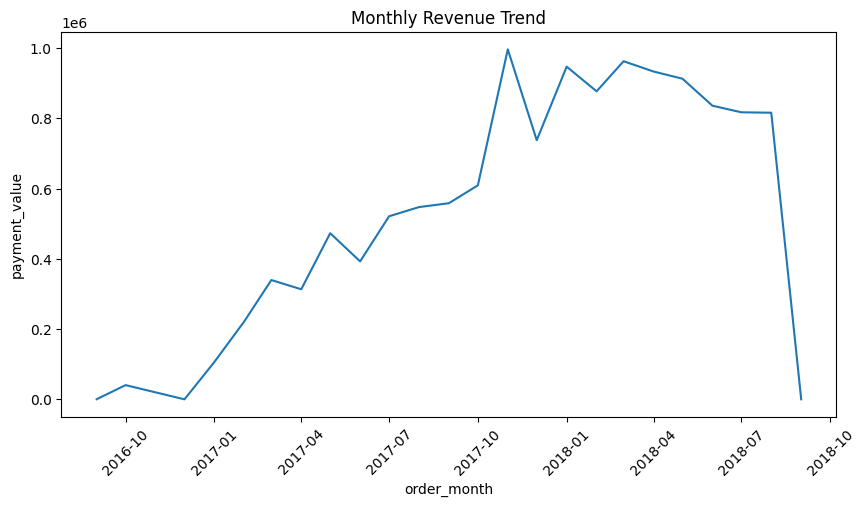

In [ ]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = df.groupby('order_month').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
monthly['order_month'] = monthly['order_month'].dt.to_timestamp()
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x='order_month', y='payment_value')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.show()

**Insight:**

- Revenue menunjukkan tren meningkat secara signifikan dari awal 2017 hingga akhir 2017.
- Puncak revenue terjadi sekitar November 2017, yang menjadi periode dengan pendapatan tertinggi.
- Setelah mencapai puncak, revenue tetap berada pada level tinggi di awal 2018 meskipun mengalami fluktuasi.
- Pada pertengahan hingga akhir 2018, terlihat adanya penurunan revenue secara bertahap.
Penurunan drastis pada bulan terakhir kemungkinan disebabkan oleh data yang tidak lengkap, sehingga tidak merepresentasikan kondisi sebenarnya.

### Pertanyaan 2:

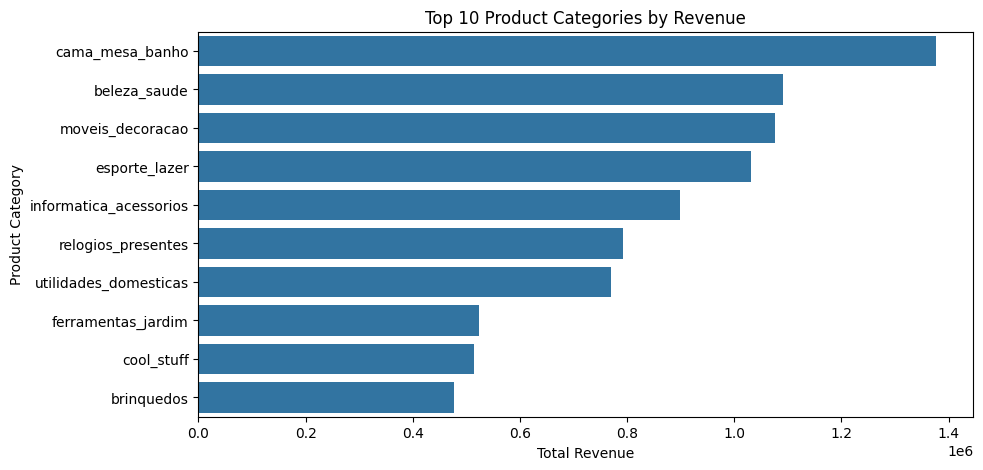

In [ ]:
top_category = category_revenue.head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_category['payment_value'], y=top_category.index)
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.show()

### Pertanyaan 3

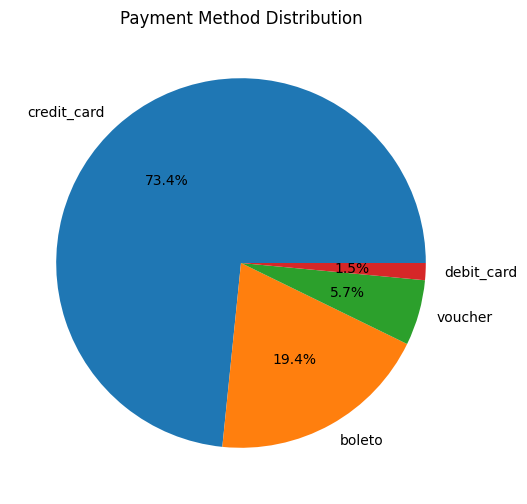

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(payment_dist, labels=payment_dist.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

**Insight:**
- Analisis tren menunjukkan bahwa jumlah order dan revenue mengalami peningkatan signifikan sepanjang tahun 2017 hingga mencapai puncaknya pada akhir tahun, sebelum mengalami fluktuasi pada tahun 2018.
- Distribusi revenue antar kategori produk tidak merata, di mana beberapa kategori seperti cama_mesa_banho dan beleza_saude mendominasi kontribusi pendapatan.
- Hal ini menunjukkan adanya kategori produk unggulan yang menjadi sumber utama revenue dalam platform.
- Dari sisi metode pembayaran, terlihat bahwa credit card merupakan metode yang paling dominan digunakan oleh pelanggan.
- Perbedaan yang signifikan antar metode pembayaran menunjukkan adanya preferensi kuat pelanggan terhadap metode tertentu dalam bertransaksi.

## Analisis Lanjutan (Opsional)

In [ ]:
# RFM Analysis
reference_date = df['order_purchase_timestamp'].max()

rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

In [ ]:
# Binning
rfm['R_score'] = pd.qcut(rfm['recency'], 3, labels=[3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 3, labels=[1,2,3])
rfm['M_score'] = pd.qcut(rfm['monetary'], 3, labels=[1,2,3])

In [ ]:
# hitung total score r f m
rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

In [ ]:
# customer segmentation
rfm['segment'] = 'Low Value'
rfm.loc[rfm['RFM_score'] >= 7, 'segment'] = 'High Value'
rfm.loc[(rfm['RFM_score'] >= 5) & (rfm['RFM_score'] < 7), 'segment'] = 'Mid Value'

In [ ]:
display(rfm.head())

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,00012a2ce6f8dcda20d059ce98491703,292,1,114.74,2,1,2,5,Mid Value
1,000161a058600d5901f007fab4c27140,413,1,67.41,1,1,1,3,Low Value
2,0001fd6190edaaf884bcaf3d49edf079,551,1,195.42,1,1,3,5,Mid Value
3,0002414f95344307404f0ace7a26f1d5,382,1,179.35,1,1,3,5,Mid Value
4,000379cdec625522490c315e70c7a9fb,153,1,107.01,3,1,2,6,Mid Value


In [ ]:
print(rfm['segment'].value_counts())

segment
Mid Value     44148
High Value    34343
Low Value     13796
Name: count, dtype: int64


In [ ]:
display(rfm.groupby('segment')[['recency','frequency','monetary']].mean())

,recency,frequency,monetary
segment,,,
High Value,159.142969,1.0,198.952014
Low Value,375.020876,1.0,61.829016
Mid Value,270.788983,1.0,119.377556


In [ ]:
df_sample = df.sample(n=20000, random_state=42) #download data untuk dashboard, karena ukuran terlalu besar untuk github sehingga dilakukan sampling agar ukuran dataset lebih kecil
df_sample.to_csv('main_data.csv', index=False)

**Insight:**
- Sebagian besar pelanggan berada pada kategori Mid Value, diikuti oleh High Value, dan paling sedikit adalah Low Value.
- Pelanggan High Value memiliki rata-rata nilai transaksi (monetary) paling tinggi dibandingkan segmen lainnya.
- Pelanggan Low Value memiliki nilai transaksi paling rendah dan recency yang lebih tinggi, menunjukkan mereka sudah lama tidak bertransaksi.
- Pelanggan Mid Value berada di antara kedua segmen tersebut dan memiliki potensi untuk ditingkatkan menjadi High Value.
- Secara umum, frekuensi transaksi cenderung rendah (sekitar 1), yang menunjukkan sebagian besar pelanggan hanya melakukan pembelian satu kali.

## Conclusion

## Conclusion

- Conclusion Question 1: Jumlah order bulanan dan revenue menunjukkan tren peningkatan selama periode 2016–2018, dengan puncak terjadi pada akhir tahun 2017 sebelum cenderung stabil pada tahun 2018. Penurunan tajam di akhir periode disebabkan oleh data yang tidak lengkap.

- Conclusion Question 2: Selama periode 2016–2018, beberapa kategori produk memberikan kontribusi yang jauh lebih besar terhadap total revenue dibandingkan kategori lainnya, yang menunjukkan adanya ketimpangan distribusi performa penjualan antar kategori.

- Conclusion Question 3: Selama periode 2016–2018, metode pembayaran credit card merupakan yang paling sering digunakan, diikuti oleh boleto, sementara metode lainnya memiliki kontribusi yang relatif kecil.